#**このファイルに直接書き込むと内容が失われてしまいます！**.
#**必ずコピーして使いましょう。**

ファイルのコピーの方法

左上の「ファイル」→「ドライブにコピーを保存」→コピーされたファイルの名前を「ファイル名_氏名.ipynb」に変更



## **注意**

前回の手書き文字認識の発展編です。前回が終わっていない人はまずは前回のをアプリまではやらなくていいのでcolabでやりましょう。<br>
https://colab.research.google.com/drive/1I3sbO4NM-o0B77fkLxwbFecE2MrEhrOX?usp=sharing

# **今回の作るもの**

学習時間短すぎて性能悲しくなっていますが気にしないでください
https://mainpy-pvjv7cuzdmdmqunqbmfzs8.streamlit.app/

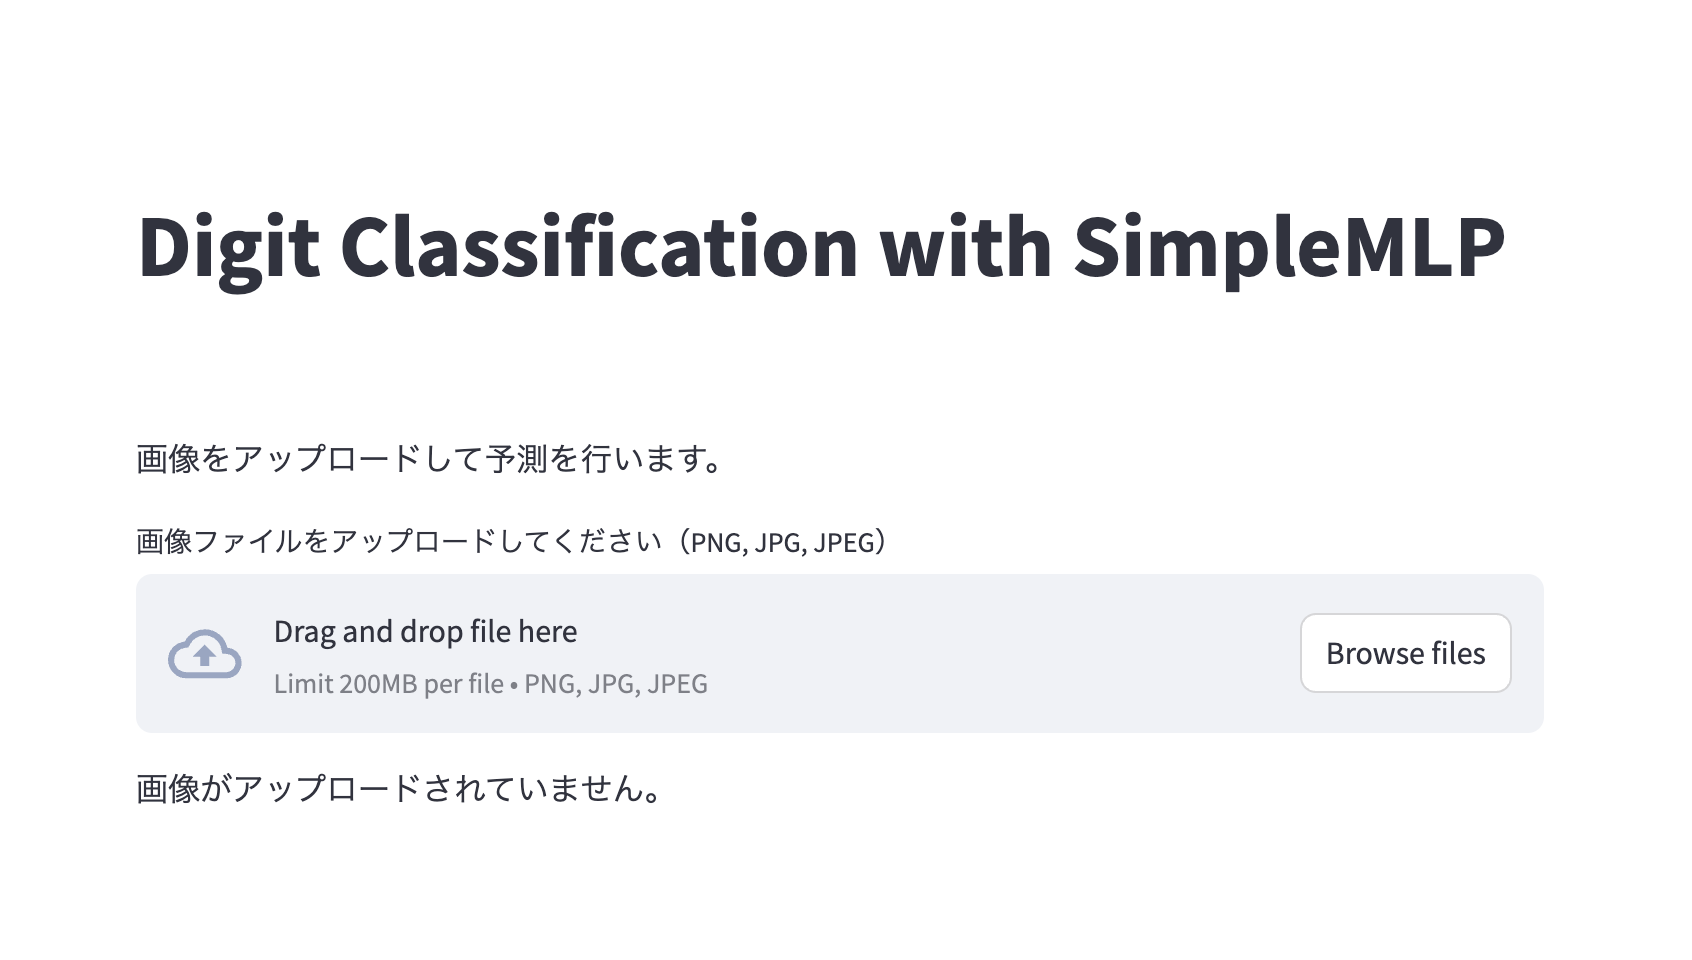

## **T4 GPUに接続**

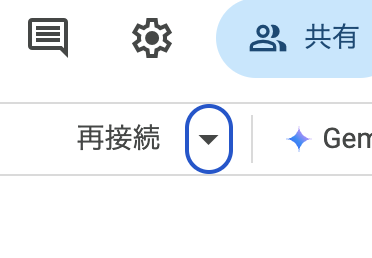

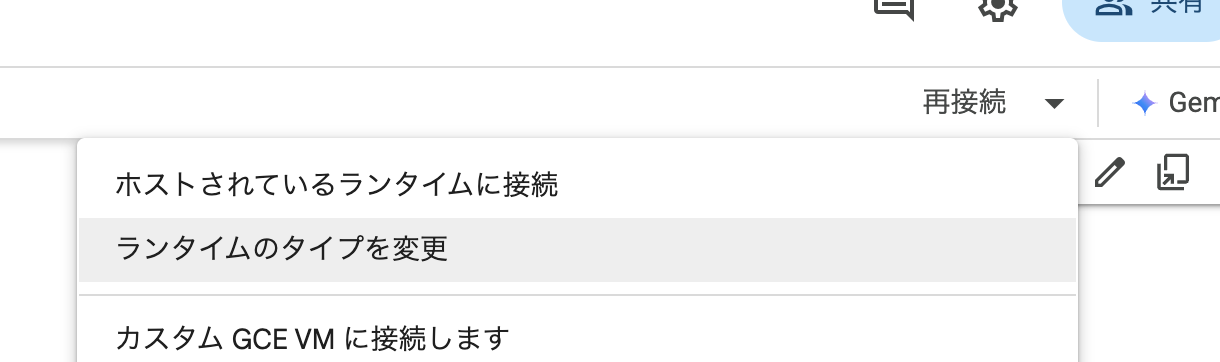

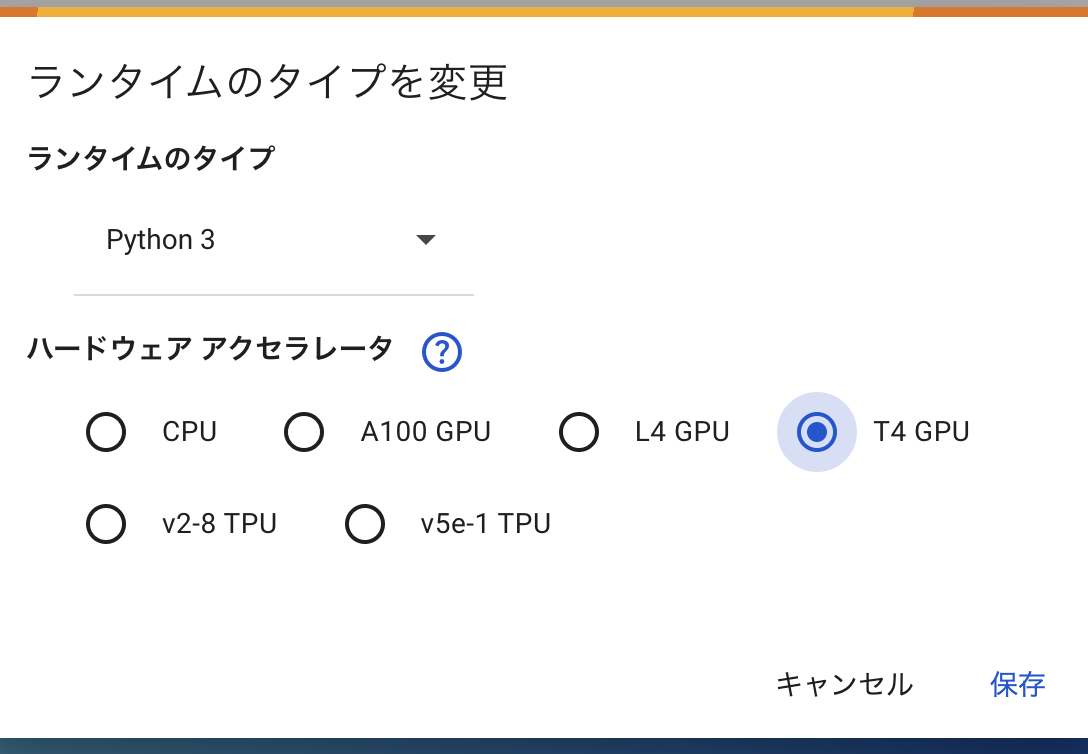

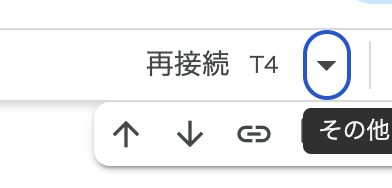

# **全体詳細**

深層学習モデルは、データセット、データサンプル、入力層、内部構造、出力層、正解ラベル、損失関数の7つからできている。これさえ正確に理解できれば怖いことはない。

図


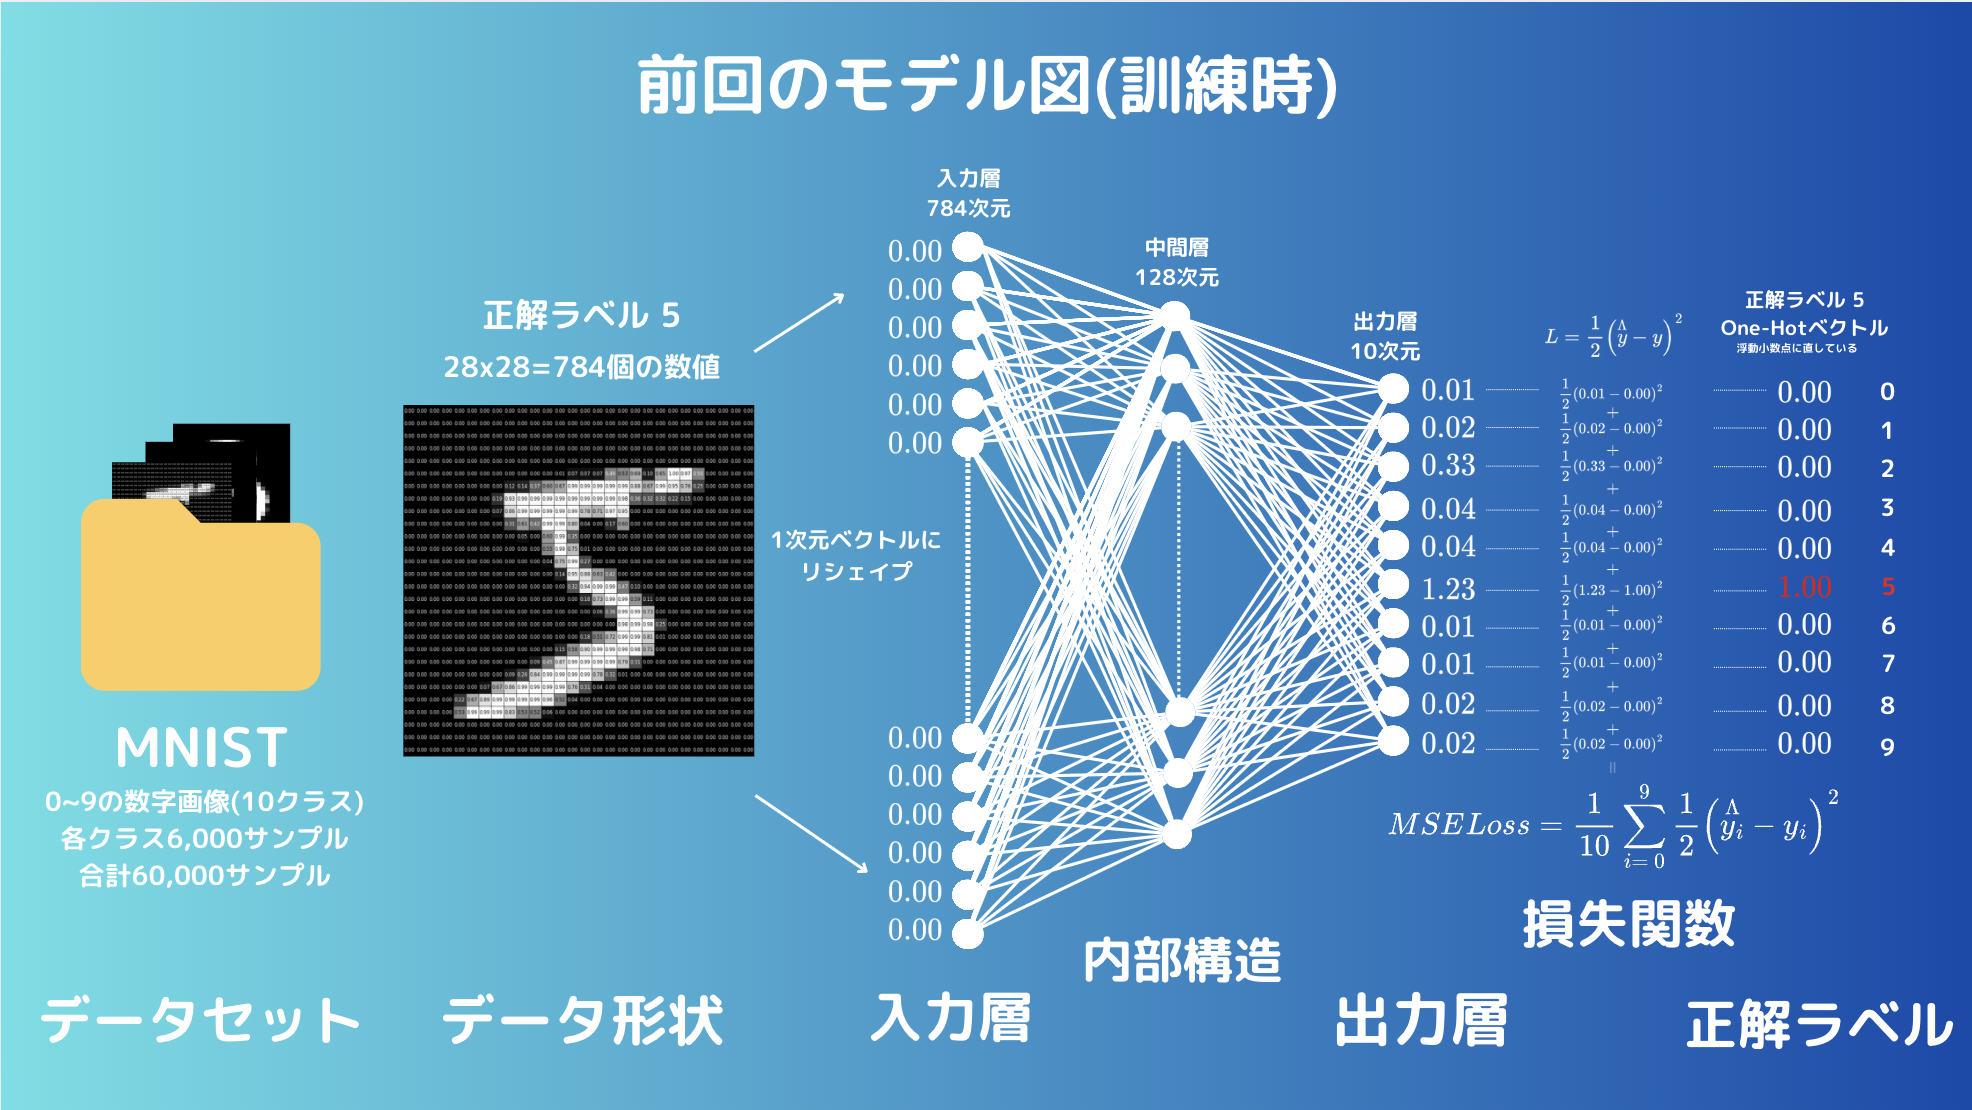

# **ライブラリをインポート**

PyTorch関連とnumpyをインポートします。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
import math
import numpy as np

テンソルを綺麗に表示する関数

In [2]:
# テンソルを見やすく表示するライブラリをインストール
!pip install git+https://github.com/HayatoHongo/print_formatted_tensor.git
# PyTorchのテンソルを見やすく表示する関数をインポート
from torch_print_tensor import print_formatted_tensor


  Cloning https://github.com/HayatoHongo/print_formatted_tensor.git to /tmp/pip-req-build-axnrlxw3
  Running command git clone --filter=blob:none --quiet https://github.com/HayatoHongo/print_formatted_tensor.git /tmp/pip-req-build-axnrlxw3
  Resolved https://github.com/HayatoHongo/print_formatted_tensor.git to commit f49215af7fa16f6b59af210897f472d421137dd4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch_print_tensor: filename=torch_print_tensor-0.0.0-py3-none-any.whl size=1775 sha256=d610d25491d35d8416cfd7e8ca3a15244a959133435d9e1c2339d5783160c7b4
  Stored in directory: /tmp/pip-ephem-wheel-cache-26ko3vw8/wheels/42/f2/8a/de376763a7e40db1b6011a73df3f759a5d4cdaf6278ffb8a4e
Successfully built torch_print_tensor


# **データセット**

## **データセットの概要**

**MNISTデータセット**は、手書き数字（0から9まで）の画像データセットです。

- **サイズ**: 28x28ピクセルのグレースケール画像、計60,000枚の学習用画像データと10,000枚のテスト用データがあります。
- **ラベル**: 各画像には数字（0〜9）のラベルが付けられています。

MNISTは、機械学習の初心者がアルゴリズムの性能を試すための標準的なデータセットです。

## **ダウンロード**

In [3]:
# MNISTの学習データ（60,000枚）とテストデータ（10,000枚）をダウンロード
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.78MB/s]


## **データセットの構造図**

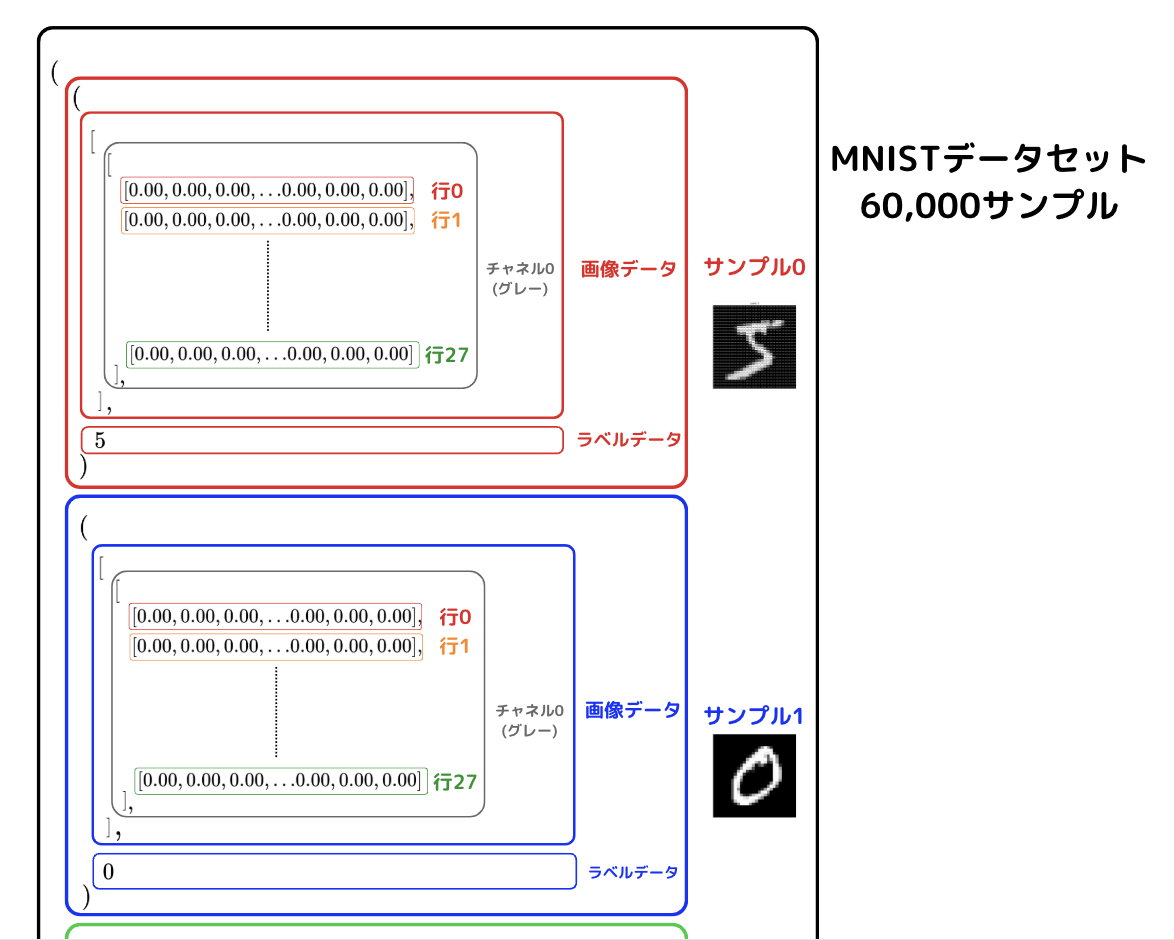

確認😘 学習用データセットについて、最初のサンプル0の画像データを表示してください！

```python
関数: print_formatted_tensor
引数: full_train_dataset[x][y] # xは取り出したいサンプル番号、yは画像なのか正解ラベルなのかを指定する
```

In [5]:
print_formatted_tensor(full_train_dataset[0][0])# 学習用データセットの形状は、（サンプル数, 画像かラベルか）= (60000, 2)
#問

Tensor Size: [1, 28, 28]
tensor([
         [
           [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
           [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
           [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
           [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
       

確認😘 学習用データセットについて、最初のサンプル0の正解ラベルデータを表示してください！

```python
関数: print
引数: full_train_dataset[x][y] # xは取り出したいサンプル番号、yは画像なのか正解ラベルなのかを指定する
```

In [6]:
print(full_train_dataset[0][1])

5


## **訓練データと検証データを用意する**

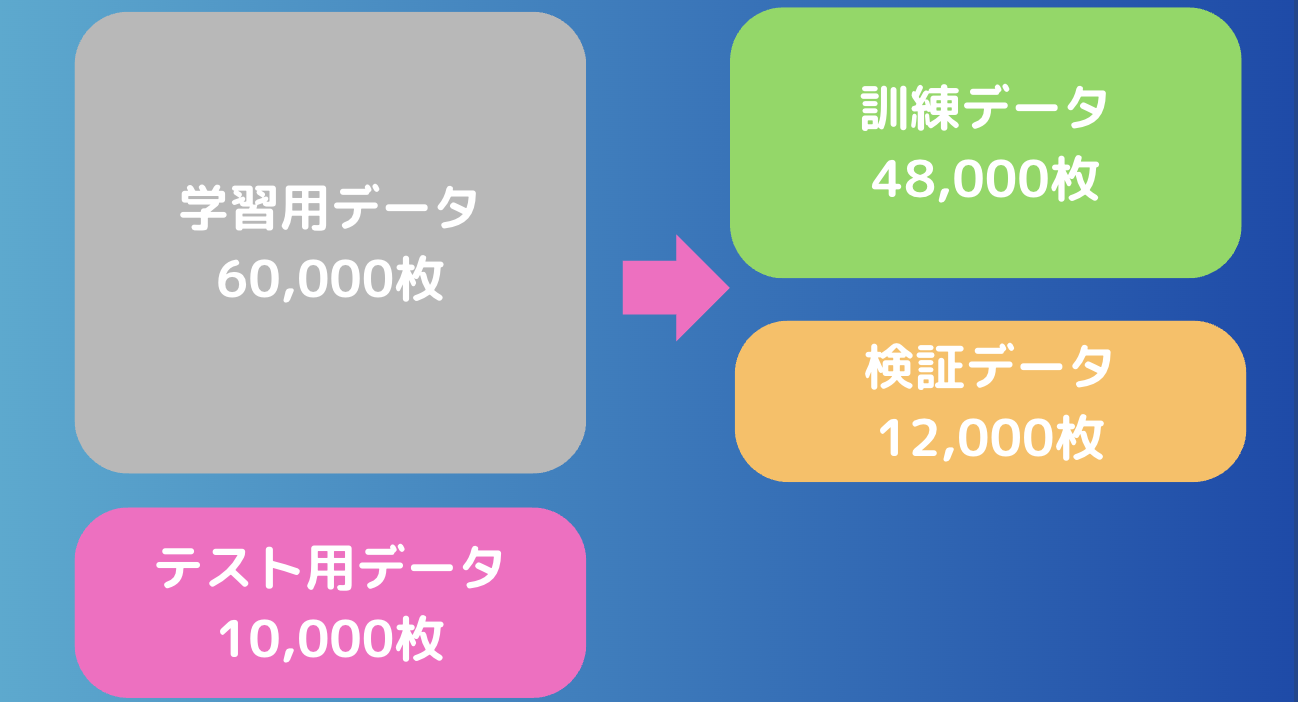

学習用データを8:2の比率で分割して、訓練データと検証データを作ろう！

```
関数: random_split
引数: データセット名, 分割後のサイズリスト[x, y]
train_subset, val_subset = 関数(引数)
```
- `random_split` は、データセットをランダムにシャッフルした後に、指定されたサイズに分割します。

- 戻り値は2つのサブセット（train_subset, val_subset）で、学習用と検証用などに使用されます。


```
例：1000枚の`data`を7:3で分割する場合
random_split(data, [700, 300])
```






In [10]:
train_subset, val_subset = random_split(full_train_dataset, [48000,12000]) #問 full_train_datasetは60,000枚。これを8:2に分割する・

train_subsetとval_subsetのサイズを確認

In [11]:
print(len(train_subset))
print(len(val_subset))

48000
12000


**`Check Point`** &nbsp; <label><input type="checkbox">訓練データと検証データが8:2に分割された
</label>

##**ミニバッチ処理**

今までは1枚の画像に対して毎回損失を計算していました。これには学習が安定しない、精度が低いという問題点があります。<br>
そこで、数十枚の画像についてそれぞれ損失を計算して、**損失の平均値を取って誤差逆伝播**を行うミニバッチ処理を行います。

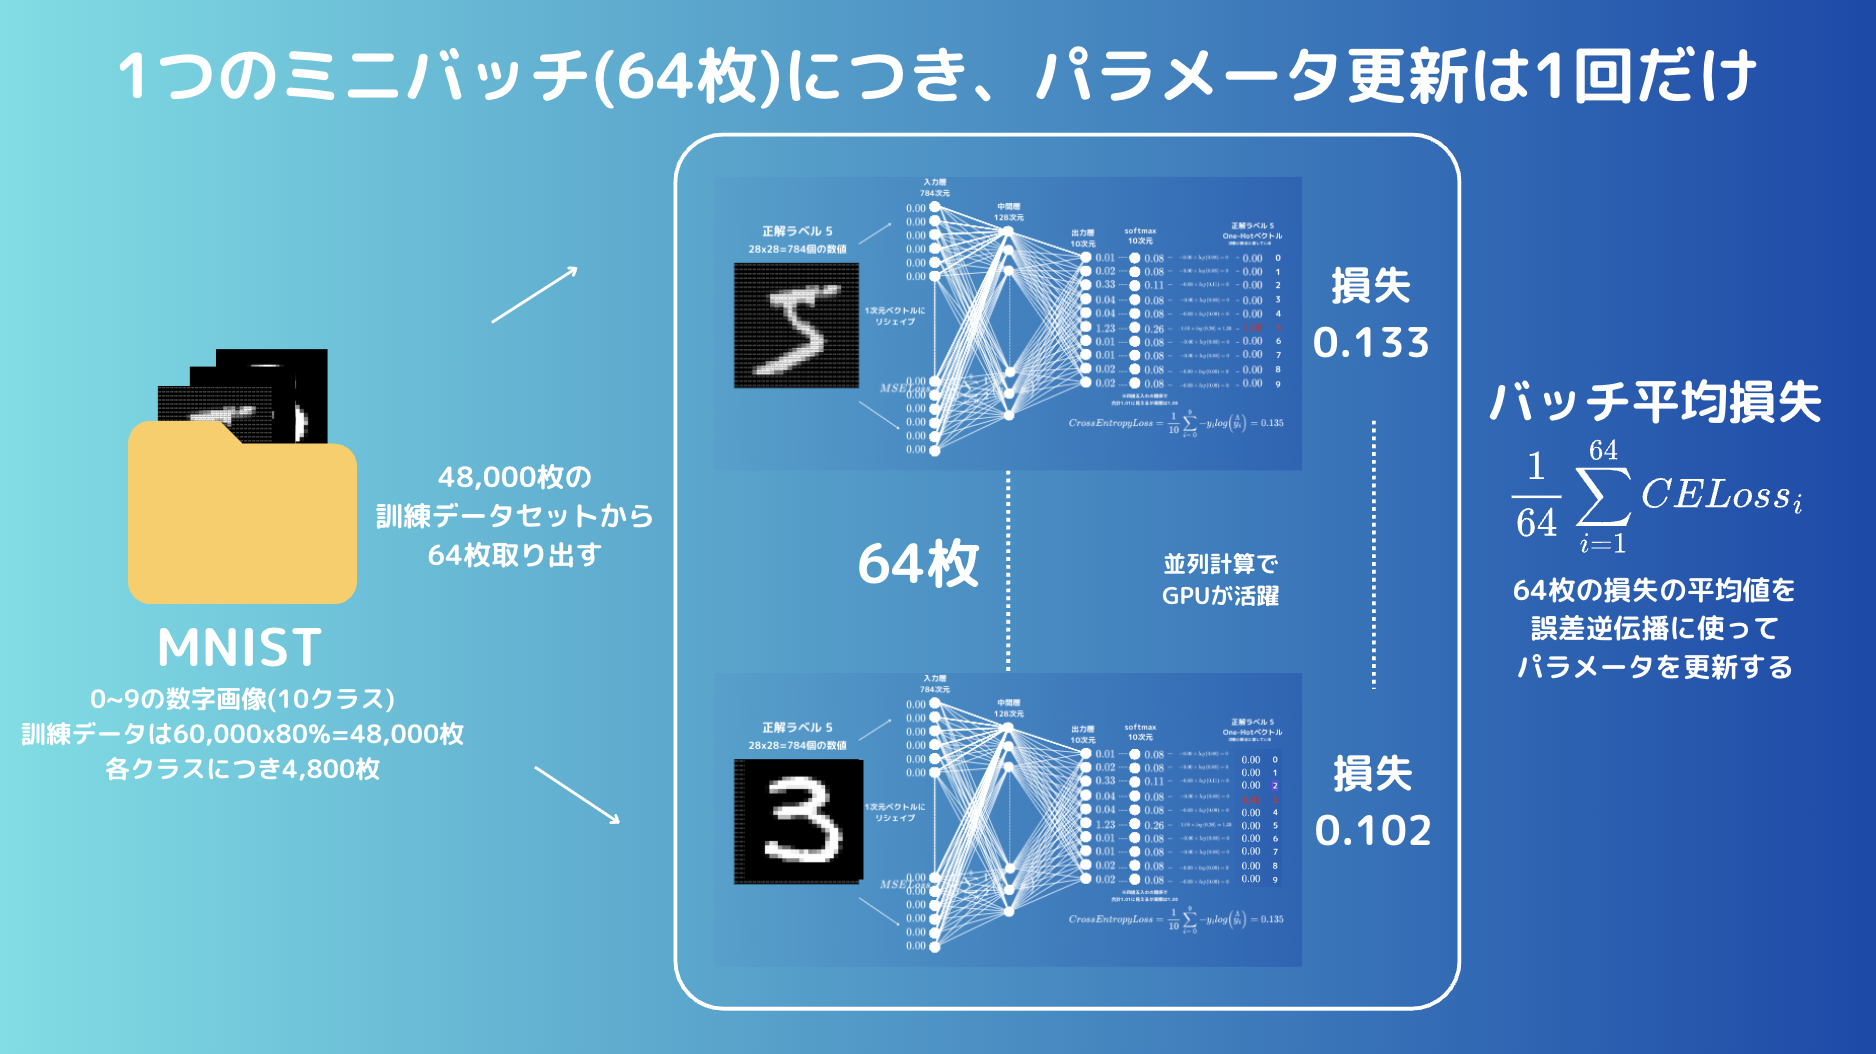

毎回１つずつ損失を計算するのではなく、複数のデータの損失平均でパラメータを更新することで特定のデータへの過剰適合を防ぎます。<br>

複数のデータを同時に処理する必要性があるので、並列処理が得意なGPUに脚光が当たるわけです。<br>

ミニバッチ学習を行うことで、メモリの使用量は増えるものの、大量のデータを効率良く活用できます。<br>

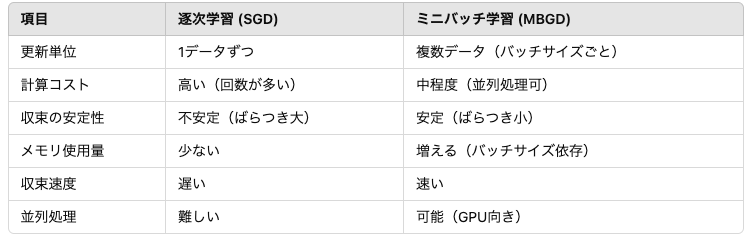

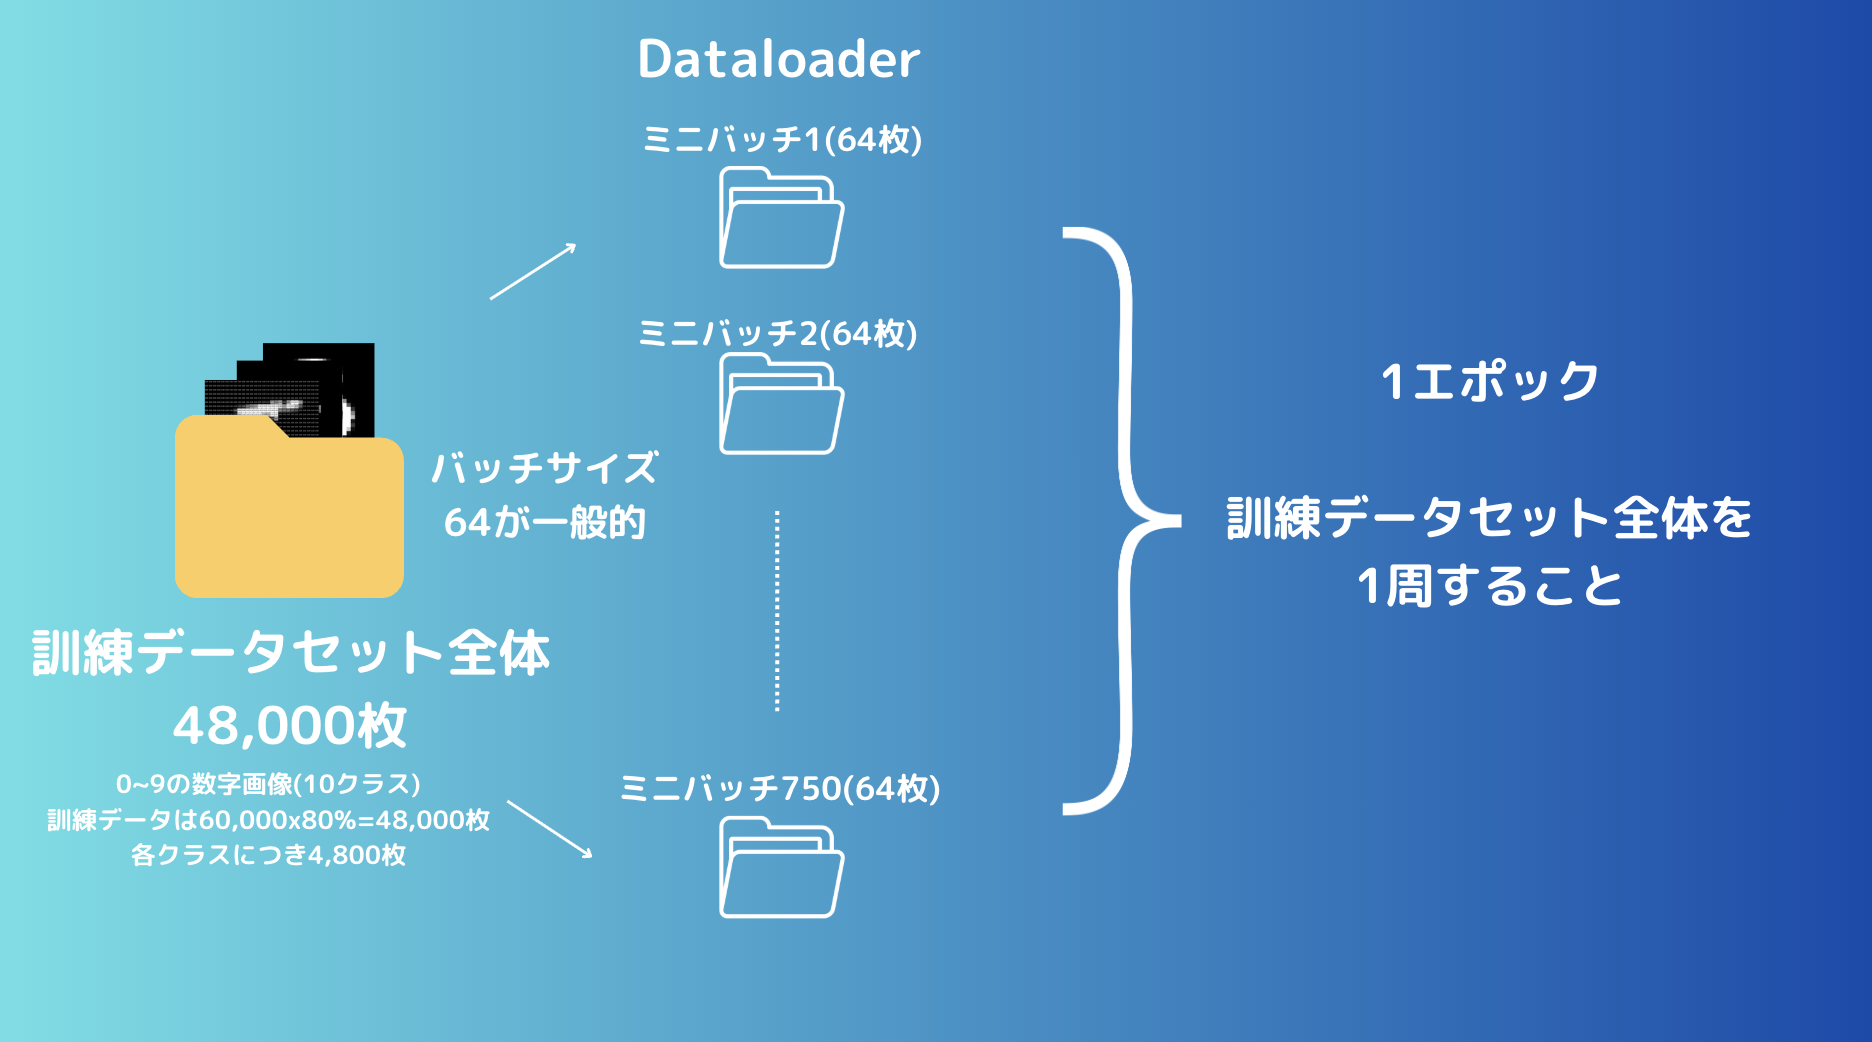

### **エポック**

訓練データセット全体を1周することを、1エポックとカウントします。

```
問 バッチサイズが64のとき、1エポックで何回、パラメータ更新が行われるでしょうか？
```

In [14]:
batch_size = 64
train_subset_size = 48000
train_steps_per_epoch = 750 #問 ヒント: ミニバッチ1つにつき1回更新なので、1エポックあたりのミニバッチの数を数えれば良い
train_steps_per_epoch

750

前回と同じ、逐次学習の場合、1回のサンプルで、パラメータ更新が1回行われます。1エポックで何回パラメータ更新が行われるしょうか？

```
問 逐次学習(SGD)の場合、1エポックで何回、パラメータ更新が行われるでしょうか？
```


In [13]:
batch_size = 1 # 逐次学習では、実質的にbatch_sizeは1と見なすことができる
train_subset_size = 48000
train_steps_per_epoch_SGD =  train_subset_size / batch_size
train_steps_per_epoch_SGD

48000.0

1エポックあたりの更新回数が、逐次学習の方が圧倒的に多いことがわかります。

## **ミニバッチ化**

ミニバッチ化はtorch.utils.data.DataLoader関数で実行されます。

```
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=False)
```



In [17]:
# バッチサイズの設定
batch_size = 64

# DataLoaderの作成
train_loader = torch.utils.data.DataLoader(train_subset,batch_size=batch_size,shuffle=True)#問 穴埋め。上記参照
val_loader = torch.utils.data.DataLoader(val_subset,batch_size=batch_size,shuffle=False)#問 穴埋め。上記参照

In [18]:
# 訓練データ train_loader から最初のミニバッチを取り出す。next(iter(train_loader))
first_batch = next(iter(train_loader))

In [19]:
# 画像データとラベルを取得
images, labels = first_batch

print("labels")
print_formatted_tensor(labels)

labels
Tensor Size: [64]
tensor([
         1.00,   2.00,   2.00,   7.00,   4.00,   1.00,   6.00,   8.00,   7.00,   6.00,   5.00,   5.00,   6.00,   8.00,   7.00,   8.00,   8.00,   4.00,   6.00,   2.00,   0.00,   7.00,   2.00,   2.00,   7.00,   3.00,   2.00,   4.00,   0.00,   8.00,   1.00,   9.00,   1.00,   8.00,   9.00,   2.00,   9.00,   8.00,   2.00,   1.00,   9.00,   9.00,   7.00,   8.00,   0.00,   5.00,   9.00,   2.00,   1.00,   3.00,   0.00,   2.00,   0.00,   8.00,   6.00,   5.00,   7.00,   6.00,   9.00,   9.00,   3.00,   8.00,   3.00,   9.00
       ])


In [20]:
print("images")
print_formatted_tensor(images)

images
Tensor Size: [64, 1, 28, 28]
tensor([
         [
           [
             [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
             [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
             [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
             [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00, 

## **学習**

入力データの形状が (1, 28, 28)から、(64, 1, 28, 28)に変化すること以外は基本的に同じです。

In [21]:
# ベースは前回のSimpleMLP
# 入力データの形状が (1, 28, 28)から、(64, 1, 28, 28)に変化すること以外は基本的に同じなので、コードは読み飛ばしても良い

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x_reshaped = x.view(x.shape[0], -1)  # (バッチサイズ, チャネル数 * 28 * 28) に変換。(64, 1, 28, 28) → (64, 784)
        h = self.fc1(x_reshaped)
        z = torch.sigmoid(h)
        y_hat = self.fc2(z)
        return y_hat

# デバイス設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = SimpleMLP().to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

cuda
SimpleMLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [22]:
# エポック数とバッチサイズの設定
num_epochs = 30 # 30 Epochで精度70%くらい
batch_size = 64#問 バッチサイズを指定する

# DataLoader を使用してデータセットをミニバッチ化
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=False)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        output_logits = model(images)  # 修正後の forward を使用
        loss = criterion(output_logits, labels) # 損失の計算
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    # バリデーションデータでの評価
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/30, Loss: 2.3077, Val Acc: 0.1852
Epoch 2/30, Loss: 2.2778, Val Acc: 0.2113
Epoch 3/30, Loss: 2.2578, Val Acc: 0.2816
Epoch 4/30, Loss: 2.2371, Val Acc: 0.3536
Epoch 5/30, Loss: 2.2151, Val Acc: 0.4373
Epoch 6/30, Loss: 2.1914, Val Acc: 0.4798
Epoch 7/30, Loss: 2.1657, Val Acc: 0.5383
Epoch 8/30, Loss: 2.1377, Val Acc: 0.5263
Epoch 9/30, Loss: 2.1069, Val Acc: 0.5502
Epoch 10/30, Loss: 2.0732, Val Acc: 0.5847
Epoch 11/30, Loss: 2.0367, Val Acc: 0.5952
Epoch 12/30, Loss: 1.9971, Val Acc: 0.6025
Epoch 13/30, Loss: 1.9547, Val Acc: 0.6235
Epoch 14/30, Loss: 1.9097, Val Acc: 0.6454
Epoch 15/30, Loss: 1.8624, Val Acc: 0.6553
Epoch 16/30, Loss: 1.8131, Val Acc: 0.6643
Epoch 17/30, Loss: 1.7625, Val Acc: 0.6740
Epoch 18/30, Loss: 1.7109, Val Acc: 0.6831
Epoch 19/30, Loss: 1.6590, Val Acc: 0.6899
Epoch 20/30, Loss: 1.6072, Val Acc: 0.7031
Epoch 21/30, Loss: 1.5560, Val Acc: 0.7045
Epoch 22/30, Loss: 1.5058, Val Acc: 0.7159
Epoch 23/30, Loss: 1.4570, Val Acc: 0.7228
Epoch 24/30, Loss: 1

## **モデルの保存**

State_dict 方式で保存する。（すぐ後に解説）

In [23]:
# モデルの重みパラメータだけを保存する
torch.save(model.state_dict(), "modelwithBatch.pth")
print("モデルの重みだけを modelwithBatch.pthとして保存しました。")

モデルの重みだけを modelwithBatch.pthとして保存しました。


保存したモデルをダウンロードする

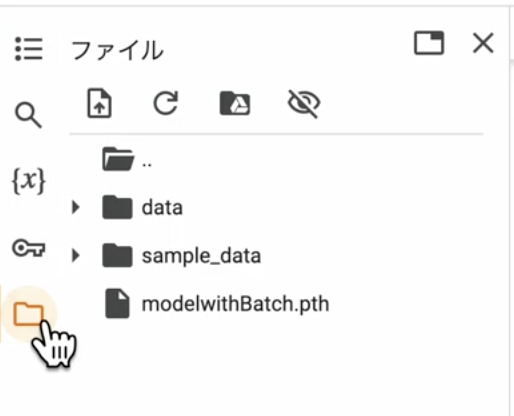

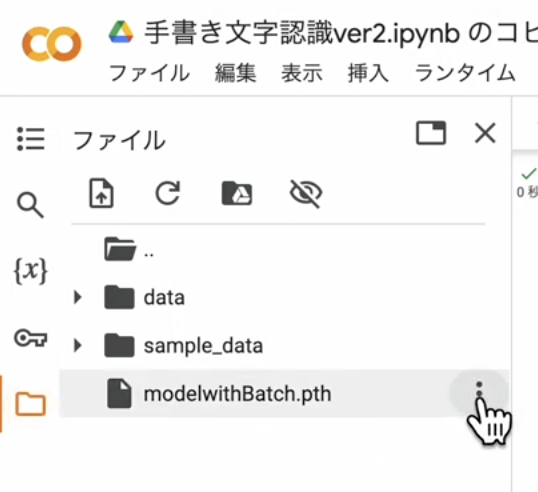

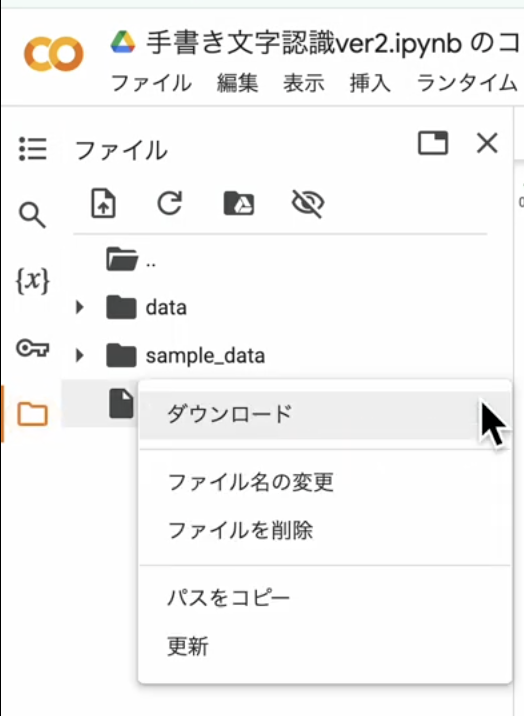

### 【超わかりやすく！】PyTorchの `.pth` ファイルとは？

作成したモデルを保存しましょう！

ニューラルネットワークのたくさんの重み${w}$パラメータが学習済みモデルの本体です！

.pthファイルというPyTorch固有のファイル形式で保存されます！

PyTorchで学習済みモデルを保存するとき、

**「重みだけ保存する方法」** と **「設計図（モデル本体）ごと保存する方法」** があります。

それぞれの違いと使い分けを、初心者にもわかりやすくまとめます！

---

## 1. **.pthファイルとは？保存の2パターン**

### ① **重みだけ保存（state\_dict方式）**

* `.pth` ファイルは**PyTorchのモデルの「重みパラメータ」だけ**を保存します。
* **モデルのクラス定義（設計図）は保存されません！**<br>
  → ロード時には「同じクラス定義」を必ず用意する必要があります。

### ② **設計図も一緒に保存（モデル本体ごと）**

* **モデルの構造（設計図）＋重みパラメータ**を**まとめて**.pthファイルに保存します。
* ロード時にクラス定義が**なくても**（ほぼ）そのまま使える場合もあります。

---

## 2. **.pthの作り方・保存方法（対比）**

### ★ 重みだけ保存（state\_dict）

```python
# モデルの重みだけ保存
torch.save(model.state_dict(), "modelwithBatch.pth")
print("モデルの重みだけを modelwithBatch.pth として保存しました。")
```

* **state_dict、何の略？**<br>
  → モデルの“現在の状態”を表すパラメータ群（＝重みやバイアスなど）を辞書型でまとめたもの

* **`model.state_dict()`**<br>
  → モデルの重み・バイアス等パラメータだけを辞書型で取得

* **`torch.save()`**<br>
  → Pythonオブジェクト（ここではstate\_dict）をファイルにシリアライズ（保存）

---

### ★ 設計図ごと保存（モデル本体）

```python
# モデル本体ごと保存
torch.save(model, "model_full.pth")
print("モデル本体ごと model_full.pth として保存しました。")
```

* モデルのクラス定義や構造を含めて、すべてまとめて保存します。

---

### 【ここ大事な対比ポイント】

| 保存方法              | 保存内容       | ロード時の要件                 |
| ----------------- | ---------- | ----------------------- |
| 重みだけ（state\_dict） | 重みパラメータだけ  | 必ず**同じクラス定義**が必要        |
| 設計図ごと保存           | 設計図＋重みまるごと | 基本はクラス定義**不要**（ただし環境依存） |

---

## 3. **.pthファイルのロード（読み込み方）**

### ★ 重みだけ保存タイプの読み込み

```python
# 1. モデルのクラス定義（設計図）を用意
model = SimpleMLP()

# 2. 重みファイルを読み込んでセット
model.load_state_dict(torch.load("modelwithBatch.pth", map_location=device, weights_only=True))
model.eval()
```

* **注意！**「保存時と**全く同じモデルクラス**」が必要です。

---

### ★ 設計図ごと保存タイプの読み込み

```python
# クラス定義がなくてもロードできる場合が多い
model = torch.load("model_full.pth", map_location=device)
model.eval()
```

* **ただし！**
  保存時とPythonの環境やライブラリバージョンが違うとうまく動かないことが多いです。

---

### 【使い分けまとめ】

| 保存方法              | メリット                      | デメリット                  |
| ----------------- | ------------------------- | ---------------------- |
| 重みだけ（state\_dict） | クラウドや他の環境で使い回しやすい、汎用性高い   | クラス定義（設計図）が必要          |
| 設計図ごと保存           | クラス定義なしで復元しやすい（同じ環境なら即復元） | 環境依存が強く、他のPCでエラーになりやすい |

---

## 4. **weights\_only=True って？**

* これを**True**にすると、「optimizer情報」など余計な情報が混じってる.pthファイルから**重みだけ**を抜き出せます。
* PyTorch 2.0以降の便利機能です（古いバージョンでは使えません）。

---

## 5. 【よくあるQ\&A】

* **Q. .pthって「モデルそのもの」なの？**<br>
  　A. 重みだけ保存とモデル本体保存の2種類ある。重みだけなら「記憶」だけ。

* **Q. 違う構造のモデルに重みだけ.pthを読ませると？**<br>
  　A. エラー！必ず同じ設計図が必要。

* **Q. どちらがおすすめ？**<br>
  　A. 実運用・クラウドデプロイなら「重みだけ保存（state\_dict）」が一般的！


→ モデル本体まで保存してしまうと、ライブラリの依存関係でエラーが出ることが非常に多いです！

そのため、ほとんどの実運用やクラウドデプロイでは「重みだけ（state\_dict）保存」が推奨されています！

⚠️ モデル定義に関して穴埋め問題あり！

In [24]:
# 以下のコードは、保存した"modelwithBatch.pth"をロードして、数字の認識を行うコードです。
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# state_dict 方式で重みだけ保存したので、モデルの設計図（クラス定義）が必ず必要です！
# 復習も兼ねて穴埋め！
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)  # TODO input: 784 -> output: 128
        self.fc2 = nn.Linear(128, 10)   # TODO input: 128 -> output: 10（10クラス分類）

    def forward(self, x):
        # バッチサイズに合わせてリシェイプ。x の形状は (batch, 1, 28, 28)
        x_reshaped = x.view(x.shape[0], -1)  # (batch, 784)
        h = self.fc1(x_reshaped)
        z = torch.sigmoid(h)
        y_hat = self.fc2(z)
        return y_hat

# デバイス設定（GPUがあればGPU、なければCPU）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# 作成したモデルをデバイスへ転送
model = SimpleMLP().to(device)
print(model)

# --- モデルのロード（重みパラメータのみのstate_dict方式） ---

# 1. モデルの設計図（クラス定義）を用意してインスタンス化
loaded_model = SimpleMLP().to(device)

# 2. 学習済みの重みパラメータ（state_dict形式の.pthファイル）を読み込んでセットする
loaded_model.load_state_dict(
    torch.load("modelwithBatch.pth", map_location=device, weights_only=True)
)

# 3. モデルを推論モード（eval）に切り替える
loaded_model.eval()

print("学習済みモデルの重みをstate_dict方式でロードし、推論モードに切り替えました。")

cuda
SimpleMLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
学習済みモデルの重みをstate_dict方式でロードし、推論モードに切り替えました。


検証データを用いて予測

### **モデルの推論と結果の表示**

細かいコードを追う必要はありませんので、以下のステップを把握してください！

| ステップ | やっていること                 | コード抜粋                                                                                                                                                                               |
| ---- | ----------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1    | 検証データ用のDataLoaderを作成    | `val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)`                                                                                                                 |
| 2    | 最初のバッチを1つだけ取り出す         | `val_batch = next(iter(val_loader))`<br>`images, labels = val_batch`                                                                                                                |
| 3    | バッチから1枚だけ画像とラベルを抜き出す    | `test_image = images[0].unsqueeze(0).to(device)`<br>`true_label = labels[0].item()`                                                                                                 |
| 4    | モデルで推論                  | `output = loaded_model(test_image)`                                                                                                                                                 |
| 5    | softmaxで確率に変換＆予測クラスを決定  | `probabilities = torch.softmax(output, dim=1)`<br>`_, predicted_class = torch.max(probabilities, 1)`                                                                                |
| 6    | 正解ラベル・予測クラス・確率をprintで表示 | `print("正解ラベル:", true_label)`<br>`print("予測されたクラス:", predicted_class.item())`<br>`print("各クラスの確率:", probabilities.cpu().numpy())`                                                   |
| 7    | 画像をMatplotlibで表示        | `plt.imshow(test_image.squeeze().cpu().numpy(), cmap='gray')`<br>`plt.title(f"True Label: {true_label}, Predicted: {predicted_class.item()}")`<br>`plt.axis('off')`<br>`plt.show()` |

---

### ざっくり流れのイメージ

1. **DataLoaderで最初のバッチを1つだけ取り出す**
   ↓
2. **さらにバッチから1枚だけテスト用に抜き出す**
   ↓
3. **モデルで推論**
   ↓
4. **正解ラベルと予測をprintで確認**
   ↓
5. **画像そのものも可視化**

---

### **ポイント解説**

* この流れは「**検証データ（val\_subset）から1枚選んでモデルで推論してみよう**」というサンプルです。
* **バッチ（かたまり）で取得して、1枚だけ抜き出す**のがポイント。


**コードの細かい中身は流してOK！この表だけ見れば何をしているか“だいたい掴める”設計です。**


正解ラベル: 6
予測されたクラス: 6
各クラスの確率: [[0.01700268 0.05894576 0.17671473 0.03710186 0.0671186  0.05428625
  0.4718187  0.00960418 0.07333888 0.03406843]]


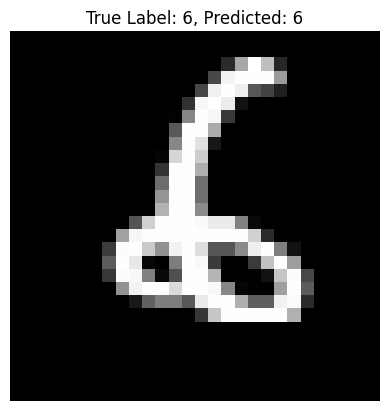

In [25]:
# ここはあまり本質的ではないので、コードは実行するだけで読み飛ばして構いません。

# --- DataLoader の作成（ここでは既に train_subset, val_subset がある前提） ---
batch_size = 64
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

# --- 検証データから1枚のテスト画像を取得して予測 ---
with torch.no_grad():
    # val_loader から最初のバッチを取得
    val_batch = next(iter(val_loader))
    images, labels = val_batch  # images: [batch, 1, 28, 28], labels: [batch]

    # バッチの先頭の画像をテスト画像として選択
    test_image = images[0].unsqueeze(0).to(device)  # 形状: [1, 1, 28, 28]
    true_label = labels[0].item()

    # モデルに入力して予測
    output = loaded_model(test_image)  # 出力形状: [1, 10]
    probabilities = torch.softmax(output, dim=1)  # 各クラスの予測確率

    # torch.maxの戻り値はタプル（最大値, 最大値のインデックス（=クラス番号））
    # 最大値は特に変数には格納せず、最大値のインデックス（=クラス番号）だけpredicted_classに格納する
    _, predicted_class = torch.max(probabilities, 1)

print("正解ラベル:", true_label)
print("予測されたクラス:", predicted_class.item())
print("各クラスの確率:", probabilities.cpu().numpy())

# --- テスト画像の表示 ---
# test_image の形状は [1, 1, 28, 28] なので、squeeze して [28, 28] に変換
test_image_disp = test_image.squeeze().cpu().numpy()
plt.imshow(test_image_disp, cmap='gray')
plt.title(f"True Label: {true_label}, Predicted: {predicted_class.item()}")
plt.axis('off')
plt.show()

以下は、逐次学習とミニバッチ学習の比較を表にしたものです：

| 項目               | 逐次学習    | ミニバッチ学習 |
| ---------------- | ------- | ------- |
| **更新回数**         | 48,000回 | 48,000回 |
| **エポック数**        | 1エポック   | 64エポック  |
| **学習時間**         | 約1分     | 約6分     |
| **Val Accuracy** | 0.8498  | 0.8524  |

# **あれ、時間に対して性能悪くなってるくないか、、？**

ミニバッチ学習は安定的ですが更新回数は少なくなるので性能向上に時間がかかることがあります。<br>
例えば、48,000サンプルが訓練データですが、逐次学習であれば1エポックで48,000回、パラメータ更新が行われます。その一方で、64枚のミニバッチ学習では、48,000 / 64 = 750回しか更新が行われません。64エポックでようやく48,000回の更新になります。GPUで並列化しているとはいえ、逐次学習1エポックと、ミニバッチ学習64エポックでは計算時間はミニバッチ学習の方が大幅に長くなります。
また、精度に関しても、特筆するようなことはありません。


ミニバッチを使用する最大の理由は、「Batch Normalization」バッチ正規化を用いることにあります。

バッチ正規化は性能が大幅に向上する神の一撃なのですが、ここでは時間がないので省略します。まじですんません。

# **Streamlitアプリにする**

## StreamlitとColabの違いは“見せ方”だけ！

### Streamlitとは？

* **Streamlit**は、Pythonコードで作ったAIモデルや処理を**WebアプリのUIとして動かせる**ライブラリです。
* 普通にPythonで `print()` してた部分が、**st.write()** などでブラウザに出るだけ。
* “Webアプリ化”といっても、**中身のモデルのロードや推論処理自体はColabや他のPython実行環境と全く同じ**です！

---

### ColabやJupyterと同じ流れ

たとえばColabで手書き数字を推論する流れと、Streamlitアプリの流れを比較するとこうなります：

| Colab / Pythonスクリプト   | Streamlitアプリ              |
| --------------------- | ------------------------- |
| 1. モデル定義・準備           | 1. モデル定義・準備               |
| 2. .pth（重み）をロード       | 2. .pth（重み）をロード           |
| 3. 画像を入力（ファイル読み込みや描画） | 3. 画像をアップロード（Web UI経由）    |
| 4. 前処理（リサイズ、正規化など）    | 4. 前処理（リサイズ、正規化など）        |
| 5. 推論                 | 5. 推論                     |
| 6. 結果をprint           | 6. 結果をst.write()やグラフで画面表示 |

**→ 3番目の「画像の入力」や、6番目の「結果の表示」の“出し方”だけ違うけど、
AIの**中身の動作（モデルのロード、画像の前処理、推論ロジック）はまったく同じ**です。**

---

## ざっくりコード解説（Streamlitアプリ）

### モデル定義・ロード

```python
class SimpleMLP(nn.Module):
    ...  # 省略

model = SimpleMLP()
model.load_state_dict(torch.load("modelwithBatch.pth", map_location=device, weights_only=True))
model.eval()
```

* **ここはColabでも全く同じ**
* `state_dict`で重みだけを保存・読み込み

---

### 入力画像を受け付ける

* Colabだと`Image.open()`などで画像ファイルパスを指定して読み込みますが、
  Streamlitだと「WebのアップローダーUI（st.file\_uploader）」になるだけ

---

### 画像の前処理・推論

```python
image_np = np.array(image) / 255.0
image_tensor = torch.tensor(image_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
output = model(image_tensor)
```

* この**画像の前処理～モデル推論の流れはColabでもStreamlitでも同じ**！

---

### 結果の表示

* Colab：`print()` や `matplotlib.pyplot.imshow()`
* Streamlit：`st.write()`, `st.image()`, `st.pyplot()`

---

## まとめ

* **Streamlitは「AIモデルのロードや推論」の“本質的な部分”には一切手を加えず、「どうやって入力を受け取るか・結果を見せるか」の部分だけをWeb化している**だけです！
* Colabで書いていたPyTorchのモデル保存・ロード・推論コードは**ほぼそのまま使えます**。
* \*\*Streamlitを使うことで「Webアプリとして一般ユーザーに触ってもらえる」\*\*のが最大のメリットです。

**要約：**

> Streamlitは、モデルのロードや推論の部分はColabなどと変わらず、
> Webアプリとして「見せ方・触り方」だけを変えているイメージです！


事前準備！

Githubアカウントを持っていること

Streamlit Communiy Cloud でSign Upする。Githubアカウントと連携させることに注意。

この数字画像をダウンロード

https://drive.google.com/file/d/1DydDaKIDbP-3NmAt5ojlRlhVxO-QkC6A/view?usp=sharing

**事前準備終了後の手順動画**

1

https://drive.google.com/file/d/1DiQNDnG4EpHhIQKxOgGTuiZjJKINvv1j/view?usp=sharing
githubのレポジトリを作るときは「公開」の設定のまま作成してください！

2

https://drive.google.com/file/d/1SyIyPS7WxW0sB4Qu37pYJizbXAR4jylM/view?usp=sharing

コピペ用コード

main.py

In [27]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 112.9 MB/s eta 0:00:00


In [31]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- モデル定義 ---
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)  # 入力: 784 -> 出力: 128
        self.fc2 = nn.Linear(128, 10)   # 入力: 128 -> 出力: 10（10クラス分類）

    def forward(self, x):
        # x の形状は (batch, 1, 28, 28) を想定。バッチサイズに合わせてリシェイプ
        x_reshaped = x.view(x.shape[0], -1)  # (batch, 784)
        h = self.fc1(x_reshaped)
        z = torch.sigmoid(h)
        y_hat = self.fc2(z)
        return y_hat

# --- デバイス設定 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- モデルのロード ---
loaded_model = SimpleMLP().to(device)
# モデルのパラメータをロード（weights_only=True を指定）
loaded_model.load_state_dict(torch.load("modelwithBatch.pth", map_location=device, weights_only=True))
loaded_model.eval()  # 推論モードに設定

st.title("Digit Classification with SimpleMLP")
st.write("画像をアップロードして予測を行います。")

# --- 画像アップロード ---
uploaded_file = st.file_uploader("画像ファイルをアップロードしてください（PNG, JPG, JPEG）", type=["png", "jpg", "jpeg"])

if uploaded_file is not None:
    # 画像を読み込み、グレースケールに変換、28x28 にリサイズ
    image = Image.open(uploaded_file).convert("L")
    image = image.resize((28, 28))
    st.image(image, caption="アップロード画像", use_column_width=False)

    # PIL Image を NumPy 配列に変換し、正規化（0～1にスケーリング）
    image_np = np.array(image) / 255.0
    # テンソルに変換：形状 [1, 28, 28] → [1, 1, 28, 28]
    image_tensor = torch.tensor(image_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

    # --- 予測処理 ---
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        output = loaded_model(image_tensor)  # 出力形状: [1, 10]
        probabilities = torch.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()

    st.write("**予測されたクラス:**", predicted_class)
    st.write("**各クラスの確率:**", probabilities.cpu().numpy())

    # --- Matplotlib を用いて画像と予測結果を表示 ---
    fig, ax = plt.subplots()
    ax.imshow(image_tensor.squeeze().cpu().numpy(), cmap="gray")
    ax.set_title(f"Prediction: {predicted_class}")
    ax.axis("off")
    st.pyplot(fig)
else:
    st.write("画像がアップロードされていません。")

Writing app.py


In [32]:
!pip install streamlit -q
!npm install -g localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 2s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙npm notice
npm notice New major version of npm available! 10.8.2 -> 11.16.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.16.0
npm notice To update run: npm install -g npm@11.16.0
npm notice
⠙

In [33]:
!wget -q -O - https://loca.lt/mytunnelpassword


34.50.175.202

In [34]:
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧your url is: https://many-things-burn.loca.lt
^C


requirements.txt

In [29]:
streamlit
torch
numpy
matplotlib
Pillow

NameError: name 'streamlit' is not defined

## エラーが出た時の対処法

9割方、ファイル名のつづりが間違っています！

よくある例：
- requirements.txt のつづりが間違っている。s忘れとか.textにしちゃうとか。
- modelwithBatch.pth のつづりが間違っている
- main.py が main(1).py みたいに間違えている


ファイル名を間違えたり、コードを変更したりしたい時は、変更したいファイルをクリックして、ペンマークから編集してください！

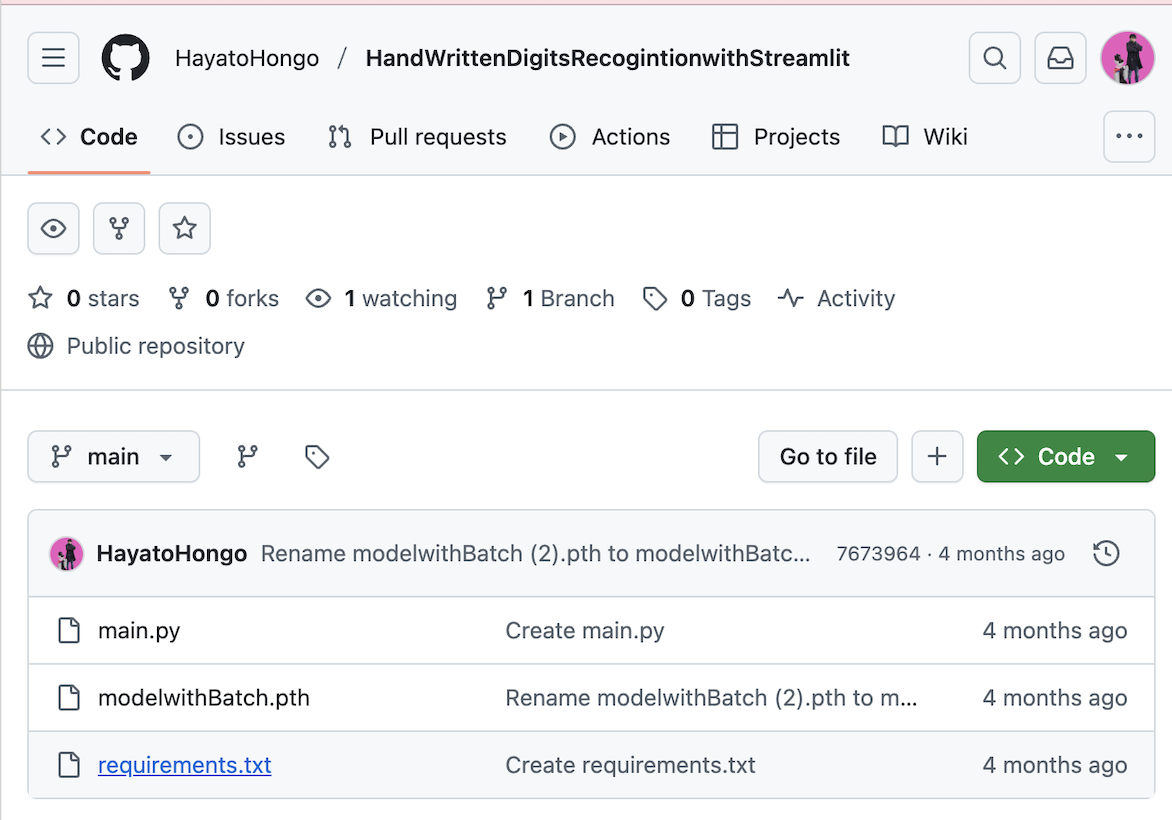

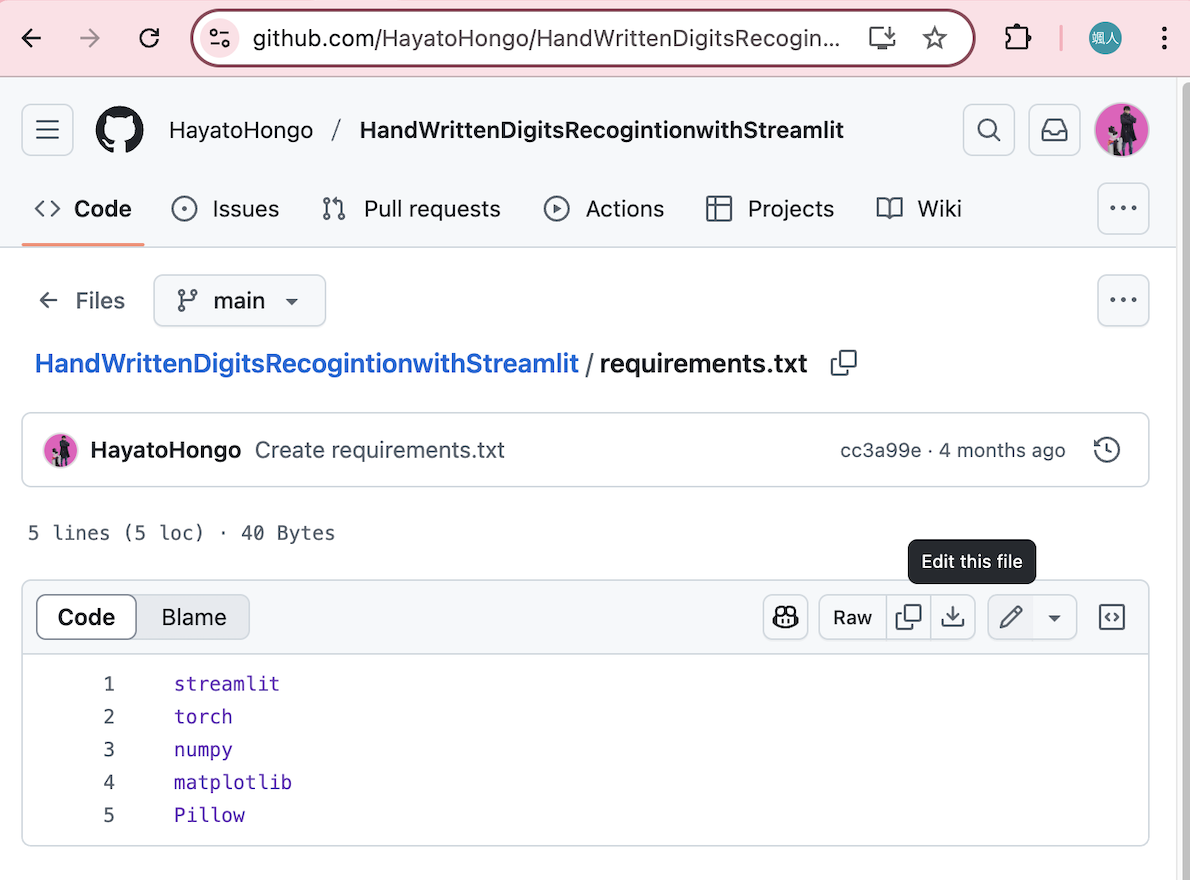

今回はすでにコピペ用コードを用意しましたが、自分で作りたい場合は、以下の手順に従ってください。

---

1. **PyTorchのソースコードを用意する**  
   モデルの定義や学習用コードを含む、PyTorchで実装したソースコードを渡します。

2. **ChatGPTへのリクエスト例**  
   例として、以下のようにリクエストしてください：
   > 「`modelwithBatch.pth`を正しくロードしてStreamlitアプリにしたいので、`main.py`と`requirements.txt`を出力してください。MNISTと同様に、背景が黒の画像を入力として想定しているため、反転操作は不要です。」

3. **重要な注意点**  
   - ファイル名を間違えてはいけません！特に、requirements.txt をつづりミスしない、.textではなく.txt にする！
   - **必ず**、PyTorchで使用しているモデルのコードおよび学習用コードも参考情報として一緒に渡してください。  
   - これを行わないと、モデルのロード時にエラーが発生する可能性があります。

---

以上の手順に従っていただければ、Streamlitアプリの作成がスムーズに進むはずです。